In [81]:
import os
import pandas as pd
import numpy as np
from src.common.utils import get_root_directory, collate_array_elements, make_directory, gridsearch
from src.common.stats import root_mean_squared_percentage_error
from src.preprocessing.data_loader import DataLoader
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, precision_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [4]:
# PARAMETERS TO CHANGE
split_size = 0.15
start_date = "01/01/2021"
end_date = "31/12/2023"
n_periods=7
split_name = "test"

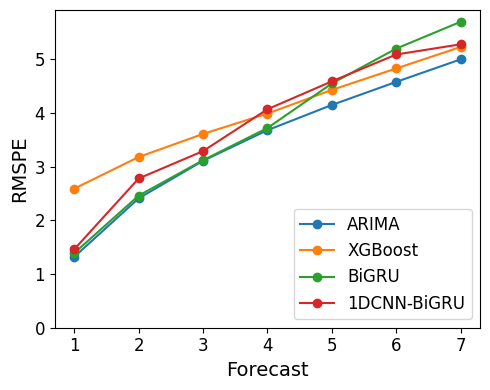

In [155]:
data = {
    "Models": ["ARIMA", "XGBoost", "BiGRU", "1DCNN-BiGRU"],
    1: [1.32, 2.59, 1.39, 1.46],
    2: [2.41, 3.18, 2.46, 2.78],
    3: [3.11, 3.61, 3.12, 3.29],
    4: [3.68, 3.99, 3.72, 4.07],
    5: [4.15, 4.43, 4.55, 4.59],
    6: [4.58, 4.83, 5.2, 5.09],
    7: [5.0, 5.23, 5.7, 5.28]
}

rmspe_df = pd.DataFrame(data)

# Set index as model names
rmspe_df.set_index("Models", inplace=True)

# Plot
plt.figure(figsize=(5, 4))
for model in rmspe_df.index:
    plt.plot(rmspe_df.columns, rmspe_df.loc[model], marker="o", label=model)

# plt.title("Model Performance Across 7 Days")
plt.xlabel("Forecast", fontsize=14)
plt.ylabel("RMSPE",fontsize=14)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks([0,1,2,3,4,5],fontsize=12)
# plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig('RMSPE.png', dpi=600, format='png', bbox_inches='tight')
plt.tight_layout()
plt.show()

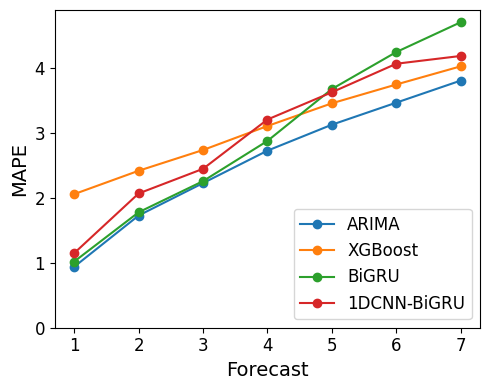

In [158]:
data = {
    "Models": ["ARIMA", "XGBoost", "BiGRU", "1DCNN-BiGRU"],
    1: [0.94, 2.06, 1.02, 1.15],
    2: [1.73, 2.42, 1.78, 2.07],
    3: [2.23, 2.74, 2.26, 2.45],
    4: [2.73, 3.11, 2.88, 3.21],
    5: [3.13, 3.46, 3.68, 3.63],
    6: [3.47, 3.75, 4.25, 4.07],
    7: [3.81, 4.03, 4.71, 4.19]
}


mape_df = pd.DataFrame(data)

# Set index as model names
mape_df.set_index("Models", inplace=True)

# Plot
plt.figure(figsize=(5, 4))
for model in mape_df.index:
    plt.plot(mape_df.columns, mape_df.loc[model], marker="o", label=model)

# plt.title("Model Performance Across 7 Days")
plt.xlabel("Forecast",fontsize=14)
plt.ylabel("MAPE",fontsize=14)
plt.legend(fontsize=12,loc="lower right")
plt.xticks(fontsize=12)
plt.yticks([0,1,2,3,4],fontsize=12)
# plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig('MAPE.png', dpi=600, format='png', bbox_inches='tight')
plt.tight_layout()
plt.show()

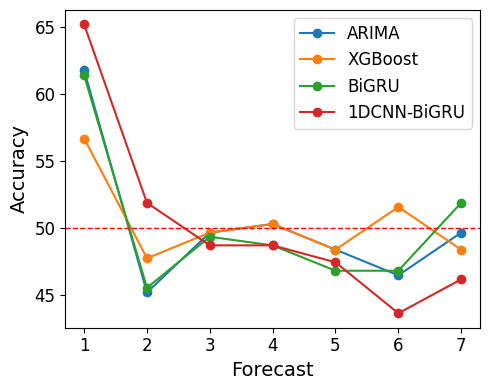

In [153]:
data = {
    "Models": ["ARIMA", "XGBoost", "BiGRU", "1DCNN-BiGRU"],
    1: [61.78, 56.69, 61.39, 65.19],
    2: [45.22, 47.77, 45.57, 51.9],
    3: [49.68, 49.68, 49.37, 48.73],
    4: [50.32, 50.32, 48.73, 48.73],
    5: [48.41, 48.41, 46.84, 47.47],
    6: [46.5, 51.59, 46.84, 43.67],
    7: [49.68, 48.41, 51.9, 46.2]
}

accuracy_df = pd.DataFrame(data)

# Set index as model names
accuracy_df.set_index("Models", inplace=True)

# Plot
plt.figure(figsize=(5, 4))
for model in accuracy_df.index:
    plt.plot(accuracy_df.columns, accuracy_df.loc[model], marker="o", label=model)
plt.axhline(y=50, color="red", linestyle="--", linewidth=1)

# plt.title("Model Performance Across 7 Days")
plt.xlabel("Forecast",fontsize=14)
plt.ylabel("Accuracy",fontsize=14)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig('Accuracy.png', dpi=600, format='png', bbox_inches='tight')
plt.tight_layout()
plt.show()

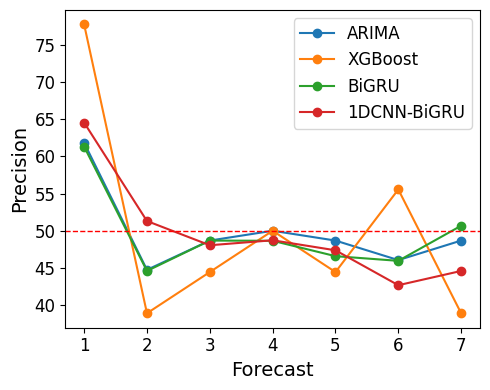

In [154]:
data = {
    "Models": ["ARIMA", "XGBoost", "BiGRU", "1DCNN-BiGRU"],
    1: [61.84, 77.78, 61.33, 64.56],
    2: [44.74, 38.89, 44.59, 51.31],
    3: [48.68, 44.44, 48.68, 48.05],
    4: [50, 50, 48.65, 48.72],
    5: [48.68, 44.44, 46.58, 47.37],
    6: [46.05, 55.56, 45.95, 42.67],
    7: [48.68, 38.89, 50.68, 44.59]
}

precision_df = pd.DataFrame(data)

# Set index as model names
precision_df.set_index("Models", inplace=True)

# Plot
plt.figure(figsize=(5, 4))
for model in precision_df.index:
    plt.plot(precision_df.columns, precision_df.loc[model], marker="o", label=model)
plt.axhline(y=50, color="red", linestyle="--", linewidth=1)
# plt.title("Model Performance Across 7 Days")
plt.xlabel("Forecast",fontsize=14)
plt.ylabel("Precision",fontsize=14)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig('Precision.png', dpi=600, format='png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## ARIMA

In [12]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
DL.set_time_range(start_date=start_date, end_date=end_date)
if split_name=="validation":
    train, test = DL.split_data(split_size=split_size)
    train, val = DL.split_data(split_type="train_val",split_size=split_size)
    test = test["ETH_D_AvgPrc"]
    train = train["ETH_D_AvgPrc"]
    val = val["ETH_D_AvgPrc"]
    split = val[:-n_periods]
    split_ungapped = val
elif split_name=="test":
    train, test = DL.split_data(split_size=0.15)
    test = test["ETH_D_AvgPrc"]
    train = train["ETH_D_AvgPrc"]
    split = test[:-n_periods]
    split_ungapped = test

In [13]:
arima_forecasts = pd.read_csv(str(os.path.join(root_dir,"mlruns","ARIMA","order_(1,1,1)_test.csv")))

In [14]:
arima_forecasts

,t1,t2,t3,t4,t5,t6,t7,t1_prc_dir,t2_prc_dir,t3_prc_dir,t4_prc_dir,t5_prc_dir,t6_prc_dir,t7_prc_dir
0,1895.395766,1896.171981,1896.944035,1897.716211,1898.488384,1899.260557,1900.032730,-1,-1,-1,-1,-1,-1,-1
1,1893.401431,1894.200366,1894.970245,1895.740982,1896.511694,1897.282406,1898.053118,-1,-1,-1,-1,-1,-1,-1
2,1869.487641,1870.489170,1871.231187,1871.980878,1872.730342,1873.479812,1874.229283,-1,-1,-1,-1,-1,-1,-1
3,1886.331927,1886.924827,1887.692611,1888.455215,1889.217973,1889.980726,1890.743479,1,1,1,1,1,1,1
4,1856.340630,1857.396103,1858.123605,1858.860822,1859.597752,1860.334690,1861.071628,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,2209.328008,2210.345501,2211.703241,2213.050469,2214.398023,2215.745566,2217.093110,1,1,1,1,1,1,1
153,2197.478807,2198.967004,2200.302163,2201.642068,2202.981826,2204.321589,2205.661351,-1,-1,-1,-1,-1,-1,-1
154,2242.761823,2243.669753,2245.064353,2246.443940,2247.823990,2249.204026,2250.584063,1,1,1,1,1,1,1
155,2308.979131,2309.744342,2311.211401,2312.656868,2314.102999,2315.549110,2316.995222,1,1,1,1,1,1,1


In [15]:
split_ungapped.head(1)

Date
2023-07-21    1893.585968
Name: ETH_D_AvgPrc, dtype: float64

## XGB

In [19]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
lag_config = {col:21 for col in DL.final_data.columns}
DL.lag_features(lag_config=lag_config)
DL.generate_forecast_horizon(horizon=n_periods)
DL.set_time_range(start_date=start_date, end_date=end_date)
if split_name=="test":
    train, test = DL.split_data(split_size=split_size)
    split = test
elif split_name=="validation":
    train, test = DL.split_data(split_size=split_size)
    train, val = DL.split_data(split_type="train_val", split_size=split_size)
    split = val

C:\Users\rajdh\Desktop\ETH_Price_Predition\src\preprocessing\data_loader.py:186: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.final_data[f"{col}_lag_{lag}"] = self.final_data[col].shift(lag)
C:\Users\rajdh\Desktop\ETH_Price_Predition\src\preprocessing\data_loader.py:186: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.final_data[f"{col}_lag_{lag}"] = self.final_data[col].shift(lag)
C:\Users\rajdh\Desktop\ETH_Price_Predition\src\preprocessing\data_loader.py:186: PerformanceWarning: DataFrame is highly fragmented.  This i

In [22]:
split.head(-1).index

DatetimeIndex(['2023-07-21'], dtype='datetime64[ns]', name='Date', freq=None)

In [23]:
xgb_forecasts = pd.read_csv(str(os.path.join(root_dir,"mlruns","XGB","ETH_base_ETH_blk_test.csv")))

In [24]:
xgb_forecasts

,t1,t2,t3,t4,t5,t6,t7,t1_prc_dir,t2_prc_dir,t3_prc_dir,t4_prc_dir,t5_prc_dir,t6_prc_dir,t7_prc_dir
0,1891.2643,1889.3103,1887.8977,1887.4521,1887.5546,1887.1808,1885.4391,-1,-1,-1,-1,-1,-1,-1
1,1891.2643,1889.3103,1887.8977,1887.4521,1887.5546,1887.1808,1885.4391,-1,-1,-1,-1,-1,-1,-1
2,1891.2643,1889.3103,1887.8977,1887.4521,1887.5546,1887.1808,1885.4391,-1,-1,-1,-1,-1,-1,-1
3,1891.2643,1889.3103,1887.8977,1887.4521,1887.5546,1887.1808,1885.4391,-1,-1,-1,-1,-1,-1,-1
4,1891.2643,1889.3103,1887.8977,1887.4521,1887.5546,1887.1808,1885.4391,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,2175.1624,2185.3223,2193.8520,2197.8838,2194.7680,2194.4553,2204.3557,-1,-1,-1,-1,-1,-1,-1
153,2175.1624,2185.3223,2193.8520,2197.8838,2194.7680,2194.4553,2204.3557,-1,-1,-1,-1,-1,-1,-1
154,2230.1929,2242.2913,2252.0293,2257.6106,2256.5852,2258.8577,2271.1748,1,1,1,1,1,1,1
155,2230.1929,2242.2913,2252.0293,2257.6106,2256.5852,2258.8577,2271.1748,-1,-1,-1,-1,-1,-1,-1


## BiGRU

In [27]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
DL.set_time_range(start_date=start_date, end_date=end_date)

if split_name=="test":
    train, test = DL.split_data(split_size=split_size, overlap=True, overlap_size=14)
    split = test
elif split_name=="validation":
    train, test = DL.split_data(split_size=split_size)
    train, val = DL.split_data(split_type="train_val", split_size=split_size, overlap=True, overlap_size=14)
    split = val

In [29]:
bigru_forecasts = pd.read_csv(str(os.path.join(root_dir,"mlruns","BiGRU","ETH_base_test.csv")))

In [31]:
bigru_forecasts[:-1]

,t1,t2,t3,t4,t5,t6,t7,t1_prc_dir,t2_prc_dir,t3_prc_dir,t4_prc_dir,t5_prc_dir,t6_prc_dir,t7_prc_dir
0,1886.0,1899.0,1892.0,1904.0,1930.0,1941.0,1945.0,-1,-1,-1,-1,-1,-1,-1
1,1888.0,1899.0,1892.0,1904.0,1930.0,1941.0,1945.0,1,-1,-1,-1,-1,-1,-1
2,1866.0,1878.0,1870.0,1882.0,1910.0,1919.0,1925.0,-1,-1,-1,-1,-1,-1,-1
3,1877.0,1888.0,1881.0,1893.0,1919.0,1930.0,1936.0,1,1,1,1,1,1,1
4,1850.0,1860.0,1855.0,1868.0,1895.0,1903.0,1910.0,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,2194.0,2204.0,2196.0,2208.0,2240.0,2248.0,2252.0,1,1,1,1,1,1,1
153,2190.0,2200.0,2190.0,2208.0,2240.0,2248.0,2252.0,-1,-1,-1,-1,-1,-1,-1
154,2236.0,2246.0,2238.0,2252.0,2288.0,2298.0,2302.0,1,1,1,1,1,1,1
155,2306.0,2320.0,2310.0,2326.0,2360.0,2372.0,2376.0,1,1,1,1,1,1,1


## 1DCNN-BiGRU

In [32]:
cnn_bigru_forecasts = pd.read_csv(str(os.path.join(root_dir,"mlruns","1DCNN-BiGRU","ETH_base_test.csv")))

In [35]:
cnn_bigru_forecasts[:-1]

,t1,t2,t3,t4,t5,t6,t7,t1_prc_dir,t2_prc_dir,t3_prc_dir,t4_prc_dir,t5_prc_dir,t6_prc_dir,t7_prc_dir
0,1906.0,1923.0,1917.0,1930.0,1936.0,1941.0,1926.0,-1,-1,-1,-1,-1,-1,-1
1,1903.0,1919.0,1912.0,1925.0,1930.0,1936.0,1921.0,-1,-1,-1,-1,-1,-1,-1
2,1881.0,1895.0,1888.0,1901.0,1906.0,1910.0,1897.0,-1,-1,-1,-1,-1,-1,-1
3,1888.0,1903.0,1897.0,1910.0,1914.0,1919.0,1906.0,1,1,1,1,1,1,1
4,1859.0,1872.0,1867.0,1879.0,1884.0,1890.0,1878.0,-1,-1,-1,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,2206.0,2246.0,2230.0,2246.0,2268.0,2278.0,2262.0,1,1,1,1,1,1,1
153,2198.0,2238.0,2224.0,2238.0,2262.0,2274.0,2256.0,-1,-1,-1,-1,-1,-1,-1
154,2258.0,2300.0,2286.0,2302.0,2324.0,2336.0,2320.0,1,1,1,1,1,1,1
155,2320.0,2366.0,2350.0,2368.0,2392.0,2406.0,2386.0,1,1,1,1,1,1,1


## Friedman's Test

In [36]:
from scipy.stats import friedmanchisquare

In [57]:
se_result = []
for i in range(7):
    actuals = pd.Series(split_ungapped[i:-n_periods+i]).reset_index(drop=True)
    data = pd.DataFrame({
        "ARIMA": (arima_forecasts[f"t{i+1}"]-actuals)**2,
        "XGB": (xgb_forecasts[f"t{i+1}"]-actuals)**2,
        "BiGRU": (bigru_forecasts[f"t{i+1}"][:-1]-actuals)**2,
        "1DCNN-BiGRU": (cnn_bigru_forecasts[f"t{i+1}"][:-1]-actuals)**2
    })
    stat, p = friedmanchisquare(
        data["ARIMA"],
        data["XGB"],
        data["BiGRU"],
        data["1DCNN-BiGRU"]
    )
    se_result.append({"forecast":i+1, "stat":stat, "p":p})

In [58]:
se_result

[{'forecast': 1, 'stat': 72.93750000000018, 'p': 1.0024784965833246e-15},
 {'forecast': 2, 'stat': 42.105431309904056, 'p': 3.8106645483289975e-09},
 {'forecast': 3, 'stat': 17.458891013384118, 'p': 0.0005686190032291285},
 {'forecast': 4, 'stat': 21.214149139579565, 'p': 9.50271051690381e-05},
 {'forecast': 5, 'stat': 18.85659411011541, 'p': 0.0002927136017053891},
 {'forecast': 6, 'stat': 22.992351816443822, 'p': 4.053152374103582e-05},
 {'forecast': 7, 'stat': 16.32865347798337, 'p': 0.0009709367022330432}]

## Wilcoxon Test - Bonferroni Corrected

In [133]:
actuals = pd.Series(split_ungapped[0:-n_periods]).reset_index(drop=True)
s = pd.Series((arima_forecasts[f"t{1}"]-actuals)**2)
sem = s.std(ddof=1) / np.sqrt(len(s))
print(sem)
mse = mean_absolute_error(actuals, arima_forecasts[f"t{1}"])
print(mse)
print(s.mean())
from scipy.stats import shapiro
stat, p_value = shapiro(s)

print(f"Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value > alpha:
    print("Fail to reject H0: Data looks normally distributed.")
else:
    print("Reject H0: Data does not look normally distributed.")

116.72997533194626
17.688275498439687
632.8241790842525
Test Statistic: 0.4322
P-value: 0.0000
Reject H0: Data does not look normally distributed.


In [72]:
from scipy.stats import wilcoxon
import itertools
from statsmodels.stats.multitest import multipletests

wilcoxon_result = []
for i in range(7):
    actuals = pd.Series(split_ungapped[i:-n_periods+i]).reset_index(drop=True)
    data = pd.DataFrame({
        "ARIMA": (arima_forecasts[f"t{i+1}"]-actuals)**2,
        "XGB": (xgb_forecasts[f"t{i+1}"]-actuals)**2,
        "BiGRU": (bigru_forecasts[f"t{i+1}"][:-1]-actuals)**2,
        "1DCNN-BiGRU": (cnn_bigru_forecasts[f"t{i+1}"][:-1]-actuals)**2
    })
    result = []
    for m1, m2 in itertools.combinations(data.columns, 2):
        stat, p = wilcoxon(data[m1], data[m2])
        result.append({"Model1": m1, "Model2": m2, "stat": stat, "p": p, "p_corrected":p*6})
    wilcoxon_result.append({'forecast':i+1, "result":result})

In [73]:
wilcoxon_result

[{'forecast': 1,
  'result': [{'Model1': 'ARIMA',
    'Model2': 'XGB',
    'stat': 1849.0,
    'p': 2.3842129976057814e-14,
    'p_corrected': 1.4305277985634687e-13},
   {'Model1': 'ARIMA',
    'Model2': 'BiGRU',
    'stat': 4565.0,
    'p': 0.004129993472112501,
    'p_corrected': 0.02477996083267501},
   {'Model1': 'ARIMA',
    'Model2': '1DCNN-BiGRU',
    'stat': 4279.0,
    'p': 0.0007536224193137423,
    'p_corrected': 0.004521734515882453},
   {'Model1': 'XGB',
    'Model2': 'BiGRU',
    'stat': 2135.0,
    'p': 1.0275147969211165e-12,
    'p_corrected': 6.165088781526699e-12},
   {'Model1': 'XGB',
    'Model2': '1DCNN-BiGRU',
    'stat': 2419.0,
    'p': 3.378675427737515e-11,
    'p_corrected': 2.0272052566425088e-10},
   {'Model1': 'BiGRU',
    'Model2': '1DCNN-BiGRU',
    'stat': 5414.0,
    'p': 0.2596297816926758,
    'p_corrected': 1.5577786901560549}]},
 {'forecast': 2,
  'result': [{'Model1': 'ARIMA',
    'Model2': 'XGB',
    'stat': 3402.0,
    'p': 9.281937064460159e-

## SHAP

### XGB

In [88]:
import pickle
import xgboost as xgb
import shap

# Path to your saved model
file_path = str(os.path.join(root_dir, "mlruns",'XGB','XGB_best.pkl'))

# Load the model
with open(file_path, "rb") as file:
    xgb_model = pickle.load(file)

In [89]:
model_type = "XGB"

n_periods = 7
start_date = "01/01/2021"
end_date = "31/12/2023"
split_size = 0.15
lags = 21
selected_data = []
ETH_base = ['ETH_D_AvgPrc']
ETH_blk = True
ETH_features = ['ETH_YF_Vol','ETH_ES_AvgTransFee','ETH_ES_BlkTm','ETH_ES_GasUsd','ETH_ES_AvgGasPrc']
filtered_features = ETH_base
run_name = "ETH_base"
if ETH_blk:
    filtered_features.extend(ETH_features)
    run_name = run_name +"_ETH_blk"
if 'BTC' in selected_data:
    filtered_features = filtered_features + BTC_features
    run_name = run_name +"_BTC_blk"
if 'LTC' in selected_data:
    filtered_features = filtered_features + LTC_features
    run_name = run_name +"_LTC_blk"
if 'sentiment_analysis' in selected_data:
    filtered_features = filtered_features + [feature for feature in sentiment_features if sentiment_type.upper() in feature]
    run_name = run_name +f"_sent_{sentiment_type}"
    
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
DL.merge_selected_data(selected_data=selected_data)
DL.select_features(features=filtered_features)
lag_config = {col:lags for col in filtered_features}
DL.lag_features(lag_config=lag_config)
DL.generate_forecast_horizon(horizon=n_periods)
DL.set_time_range(start_date=start_date, end_date=end_date)
if split_name=="test":
    train, test = DL.split_data(split_size=split_size)
    split = test
elif split_name=="validation":
    train, test = DL.split_data(split_size=split_size)
    train, val = DL.split_data(split_type="train_val", split_size=split_size)
    split = val
features = [col for col in train.columns if 'lag' in col]
targets = [col for col in train.columns if'horizon' in col]
train = train[:-n_periods]
split = split[:-n_periods]
y_scaler = MinMaxScaler()
x_scaler = MinMaxScaler()
y_train, x_train = y_scaler.fit_transform(train[targets].to_numpy()), x_scaler.fit_transform(train[features].to_numpy())
y_val, x_val = split[targets].to_numpy(), x_scaler.transform(split[features].to_numpy())

C:\Users\rajdh\Desktop\ETH_Price_Predition\src\preprocessing\data_loader.py:186: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.final_data[f"{col}_lag_{lag}"] = self.final_data[col].shift(lag)
C:\Users\rajdh\Desktop\ETH_Price_Predition\src\preprocessing\data_loader.py:186: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.final_data[f"{col}_lag_{lag}"] = self.final_data[col].shift(lag)
C:\Users\rajdh\Desktop\ETH_Price_Predition\src\preprocessing\data_loader.py:186: PerformanceWarning: DataFrame is highly fragmented.  This i

In [90]:
xgb_model.predict(x_val)

array([[0.2863198 , 0.28260624, 0.25836653, ..., 0.23147361, 0.23137416,
        0.2309106 ],
       [0.2863198 , 0.28260624, 0.25836653, ..., 0.23147361, 0.23137416,
        0.2309106 ],
       [0.2863198 , 0.28260624, 0.25836653, ..., 0.23147361, 0.23137416,
        0.2309106 ],
       ...,
       [0.37019384, 0.37035283, 0.3518978 , ..., 0.3296888 , 0.3302936 ,
        0.33357173],
       [0.37019384, 0.37035283, 0.3518978 , ..., 0.3296888 , 0.3302936 ,
        0.33357173],
       [0.37019384, 0.37035283, 0.3518978 , ..., 0.3296888 , 0.3302936 ,
        0.33357173]], dtype=float32)

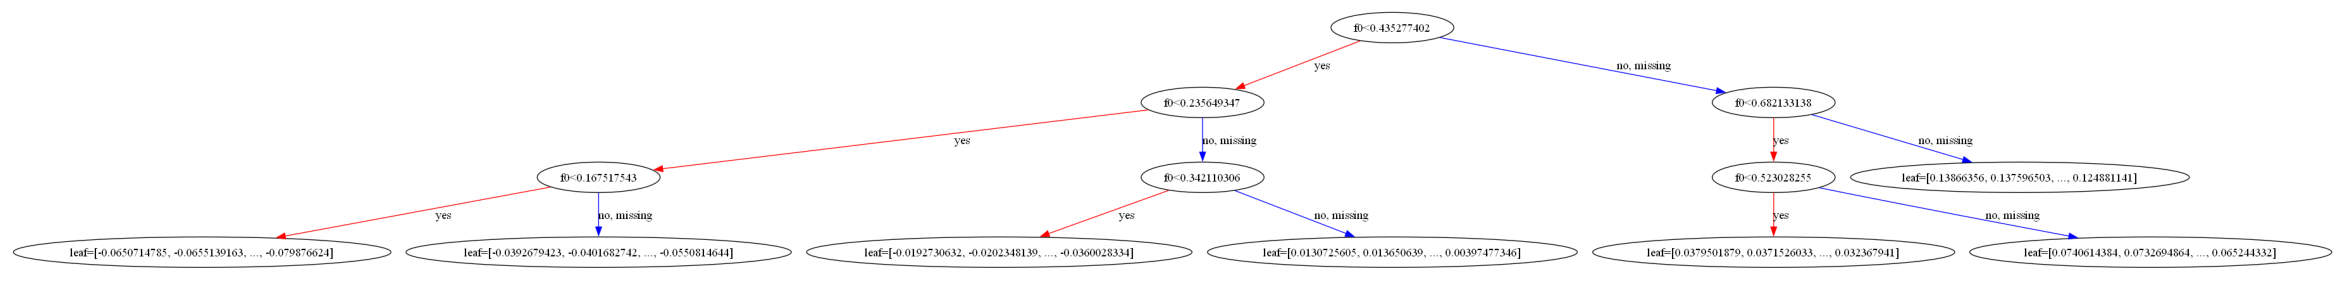

In [92]:
from xgboost import plot_tree

plot_tree(xgb_model)
fig = plt.gcf()
fig.set_size_inches(30, 15)  # optional: resize
# plt.savefig("xgboost_tree_gamma_1_10000000_1.png", dpi=300, bbox_inches='tight')  # Save the figure
plt.show()

In [99]:
split[features].columns[0]

'ETH_D_AvgPrc_lag_1'

In [100]:
split[features].columns[58]

'ETH_ES_AvgTransFee_lag_17'

In [101]:
split[features].columns[5]

'ETH_D_AvgPrc_lag_6'

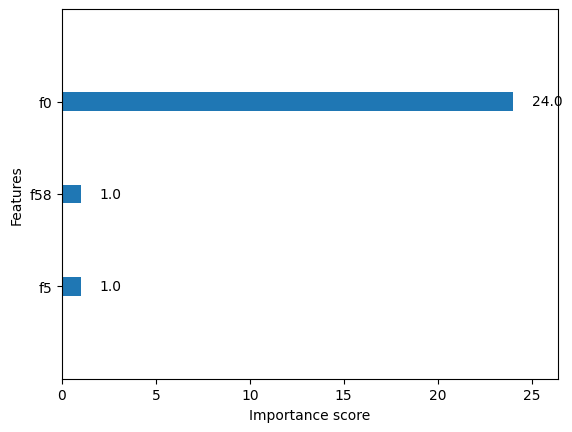

In [120]:
booster = xgb_model.get_booster()
xgb.plot_importance(booster,grid=False,max_num_features=10,title=None,importance_type="weight")  # "weight", "gain", or "cover"
plt.show()

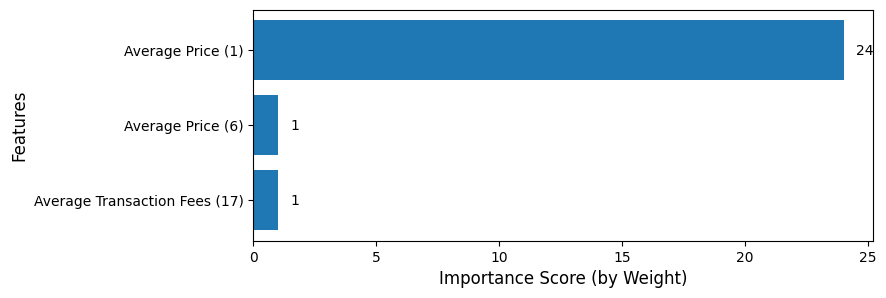

In [184]:
data = {
    "Features": ["Average Price (1)", "Average Price (6)", "Average Transaction Fees (17)"],
    "Importance Score (Weight)": [24, 1, 1]
}

feaure_importance = pd.DataFrame(data)

# Plot
plt.figure(figsize=(8, 3))
bars = plt.barh(feaure_importance["Features"], feaure_importance["Importance Score (Weight)"])
plt.xlabel('Importance Score (by Weight)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.gca().invert_yaxis()  # Optional: largest value on top
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             str(width), va='center')
plt.savefig('feature_importances.png', dpi=600, format='png', bbox_inches='tight')
plt.show()

### BiGRU

In [171]:
import tensorflow as tf

# Path to the SavedModel directory (not just the .pb file)
bigru_model_path = str(os.path.join(root_dir, "mlruns",'BiGRU','BiGRU_best.keras'))

# Load the model
bigru_model = tf.keras.models.load_model(bigru_model_path)

In [172]:
model_type = "BiGRU"

n_periods = 7
start_date = "01/01/2021"
end_date = "31/12/2023"
split_size = 0.15
lags = 14
selected_data = []
sentiment_type = "cryptobert"
ETH_base = ['ETH_D_AvgPrc']
ETH_blk = False
ETH_features = ['ETH_D_PrcDir']
BTC_features = ['BTC_D_AvgPrc']
LTC_features = ['LTC_D_AvgPrc']
sentiment_features = ['D_VADER_AvgScr_Ex', 'D_VADER_Sent_AvgEx','D_FINBERT_AvgScr_Ex','D_FINBERT_Sent_AvgEx','D_CRYPTOBERT_AvgScr_Ex','D_CRYPTOBERT_Sent_AvgEx']
filtered_features = ETH_base
run_name = "ETH_base"
if ETH_blk:
    filtered_features.extend(ETH_features)
    run_name = run_name +"_ETH_blk"
if 'BTC' in selected_data:
    filtered_features = filtered_features + BTC_features
    run_name = run_name +"_BTC_blk"
if 'LTC' in selected_data:
    filtered_features = filtered_features + LTC_features
    run_name = run_name +"_LTC_blk"
if 'sentiment_analysis' in selected_data:
    filtered_features = filtered_features + [feature for feature in sentiment_features if sentiment_type.upper() in feature]
    run_name = run_name +f"_sent_{sentiment_type}"

split_name = "test"
experiment_name = f"{model_type}_train_{split_name}"

In [173]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
DL.merge_selected_data(selected_data=selected_data)
DL.select_features(features=filtered_features)
DL.set_time_range(start_date=start_date, end_date=end_date)

if split_name=="test":
    train, test = DL.split_data(split_size=split_size, overlap=True, overlap_size=lags)
    split = test
elif split_name=="validation":
    train, test = DL.split_data(split_size=split_size)
    train, val = DL.split_data(split_type="train_val", split_size=split_size, overlap=True, overlap_size=lags)
    split = val
y_train, x_train = DL.generate_X_y_tensors(train, data_split="train", lags=lags, horizon=n_periods, tensor_format="numpy")
y_val, x_val = DL.generate_X_y_tensors(split, data_split=split_name, lags=lags, horizon=n_periods, tensor_format="numpy")

In [203]:
background = x_train

# initialize GradientExplainer with model and its input tensor
explainer = shap.GradientExplainer(
    bigru_model,  # model + first input layer
    background
)

# explain a few validation samples
shap_values = explainer.shap_values(x_val)


C:\Users\rajdh\AppData\Local\Temp\ipykernel_22032\1797765867.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


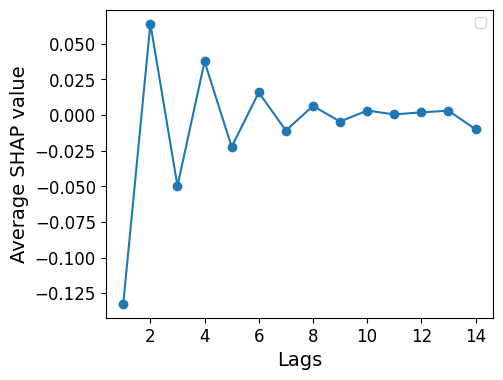

In [207]:
shap_mean = np.mean(shap_values, axis=0)  # shape: (14, 7)

# flip timesteps to go from oldest (1) → newest (14)
shap_mean = shap_mean[::-1, :]
shap_mean = shap_mean.mean(axis=2).squeeze()
# plot
plt.figure(figsize=(5,4))
plt.plot(range(1, 15), shap_mean, marker='o')
plt.xlabel("Lags", fontsize=14)
plt.ylabel("Average SHAP value", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.savefig('bigru_shap.png', dpi=600, format='png', bbox_inches='tight')
plt.show()

### 1DCNN-BiGRU

In [186]:
cnn_bigru_model_path = str(os.path.join(root_dir, "mlruns",'1DCNN-BiGRU','1DCNN-BiGRU_best.keras'))

# Load the model
cnn_bigru_model = tf.keras.models.load_model(cnn_bigru_model_path)

C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 58 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [208]:
background = x_train

# initialize GradientExplainer with model and its input tensor
explainer = shap.GradientExplainer(
    cnn_bigru_model,  # model + first input layer
    background
)

# explain a few validation samples
shap_values = explainer.shap_values(x_val)

C:\Users\rajdh\AppData\Local\Temp\ipykernel_22032\3856646460.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


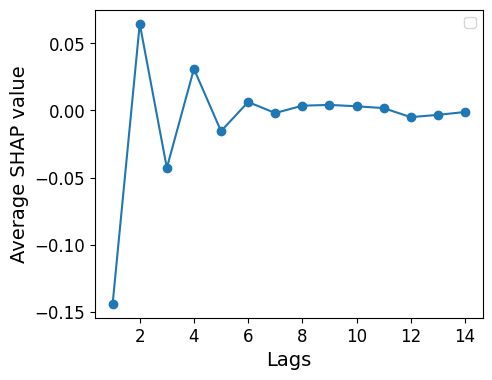

In [209]:
shap_mean = np.mean(shap_values, axis=0)  # shape: (14, 7)

# flip timesteps to go from oldest (1) → newest (14)
shap_mean = shap_mean[::-1, :]
shap_mean = shap_mean.mean(axis=2).squeeze()
# plot
plt.figure(figsize=(5,4))
plt.plot(range(1, 15), shap_mean, marker='o')
plt.xlabel("Lags", fontsize=14)
plt.ylabel("Average SHAP value", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels)
plt.legend()
plt.savefig('1dcnn-bigru_shap.png', dpi=600, format='png', bbox_inches='tight')
plt.show()

In [200]:
for h in range(shap_mean.shape[1]):
    print(shap_mean[:,h].shape)

(14, 7)
